In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
from rdkit.Chem import PandasTools
from rdkit.DataStructs import ExplicitBitVect

import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
%reload_ext autoreload
%autoreload 2
def warn(*args, **kwargs):
    pass 
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import sys
from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle
Draw.DrawingOptions.atomLabelFontFace = "DejaVu Sans"
Draw.DrawingOptions.atomLabelFontSize = 18




UsageError: Line magic function `%autoreload` not found.


In [2]:
# Function to read SDF file into DataFrame
def load_sdf_to_df(filename):
    suppl = Chem.SDMolSupplier(filename)
    rows = []
    for mol in suppl:
        if mol is not None:
            row = {prop: mol.GetProp(prop) for prop in mol.GetPropNames()}
            row['SMILES'] = Chem.MolToSmiles(mol)
            rows.append(row)
    return pd.DataFrame(rows)

# Load the  test sets from SDF files
test_df = load_sdf_to_df(r'C:\Users\User\Documents\KULIAH TELKOM S1\SKRIPSI\UJI COBA QSAR - PRIBADI\Skin Irritation\dataset\tes_set_skin_irritation_features_rdkitcdk.sdf')

# Convert strings back to lists of integers
def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string


test_df['Morgan_Descriptors'] = test_df['Morgan_Descriptors'].apply(string_to_list)
test_df['MACCS_Descriptors'] = test_df['MACCS_Descriptors'].apply(string_to_list)

def string_to_list(descriptor):
    if isinstance(descriptor, str):
        return list(map(float, descriptor.strip('[]').split(',')))
    return descriptor

# Apply the function to the 'Modred_Descriptor' column
test_df['Modred_Descriptor'] = test_df['Modred_Descriptor'].apply(string_to_list)

# Convert 'Modred_Descriptor' column to a NumPy array
data_modred_test = np.array(test_df['Modred_Descriptor'].tolist())


print("Test DataFrame:")
print(test_df.head())


Test DataFrame:
  Outcome RowID                                 Morgan_Descriptors  \
0       1   185  [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, ...   
1       0   297  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2       0   515  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
3       0   299  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...   
4       0   464  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   MACCS_Descriptors  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
3  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
4  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                   Modred_Descriptor   ID  \
0  [-0.33546491193985767, -1.0152756893381816, -0...  185   
1  [3.661806524504995, 0.8355237457375205, 0.9019...  297   
2  [-1.0952040855758334, -1.890792479825778

In [3]:
test_df

,Outcome,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,ID,SMILES,Molecular Weight,logP,LabuteASA,...,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3
0,1,185,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.33546491193985767, -1.0152756893381816, -0...",185,CC(C)CCCCCOC(=O)CS,204.11840088,2.675800000000001,86.45386405035137,...,0.0,7.0,11.0,0.5,8.0,0.0,65.1,4.584962500721156,3.95,0.9
1,0,297,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[3.661806524504995, 0.8355237457375205, 0.9019...",297,COc1cc(NC(=O)/C(=N/Nc2ccc(-c3ccc(N/N=C(\C(C)=O...,816.103572704,7.992800000000005,329.22569108280004,...,4.0,4.0,5.0,0.4814814814814814,17.0,3.0,178.03999999999996,6.832890014164742,12.134000000000002,0.1666666666666666
2,0,515,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-1.0952040855758334, -1.8907924798257785, -1....",515,CNC(N)=O,74.048012812,-0.7155,30.155468122890678,...,2.0,0.0,4.0,0.3333333333333333,1.0,0.0,55.12,3.0,-1.168,0.5
3,0,299,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[4.033357398728489, 1.241771623955365, 1.31421...",299,O=C(Nc1cc(Cl)c(NC(=O)c2cc3ccccc3c(N=Nc3cc(Cl)c...,859.9833692640002,14.659999999999984,347.47738235798045,...,4.0,0.0,3.0,0.48,10.0,2.0,148.1,6.954196310386876,14.509999999999998,0.0
4,0,464,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.6400987053850026, -0.04273934527461484, 0....",464,N#Cc1ccccc1Cl,137.003226808,2.2116800000000003,58.49219114224396,...,0.0,0.0,2.0,0.4,0.0,0.0,23.79,4.169925001442312,2.367,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0,479,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.48873838390132374, -1.4750688375425567, -1...",479,CCCCOCOCCCC,160.14632988,2.577300000000001,69.88587840201616,...,0.0,4.0,11.0,0.5,8.0,0.0,18.46,4.321928094887363,2.6670000000000003,1.0
107,0,437,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.451971462565586, -0.31527624691270373, -0....",437,CC(=O)OCc1ccccc1,150.06807956,1.7496999999999998,65.80129679223744,...,0.0,2.0,4.0,0.4285714285714285,3.0,0.0,26.3,4.459431618637298,1.951,0.2222222222222222
108,0,548,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.8932677731007405, -1.2883778680089641, -1....",548,CCCC(O)CO,104.083729624,0.13970000000000005,43.787486989808,...,2.0,5.0,6.0,0.4,3.0,0.0,40.46,3.584962500721156,0.1789999999999998,1.0
109,1,62,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.5752952895139698, -1.1381678094099679, -1....",62,CN(C)CCOCCN(C)C,160.15756326,0.1262000000000003,69.9270583985194,...,0.0,2.0,9.0,0.5,6.0,0.0,15.71,4.321928094887363,-0.274,1.0


In [4]:
test_df= test_df.sort_values(['Outcome'], ascending=True)
test_df.head(100)

,Outcome,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,ID,SMILES,Molecular Weight,logP,LabuteASA,...,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3
110,0,361,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.5441383428952367, 0.12383288877765863, 0.17...",361,CC(CN=Cc1ccccc1O)N=Cc1ccccc1O,282.136827816,3.0243000000000015,123.69232037365632,...,2.0,3.0,6.0,0.4615384615384615,5.0,0.0,65.18,5.459431618637297,3.3560000000000008,0.1764705882352941
35,0,517,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.24689294768837985, 0.3055417593701029, 0.3...",517,CCO[Si](CCCCl)(OCC)OCC,240.09484874199998,2.6637000000000013,93.0536626905066,...,0.0,3.0,8.0,0.4285714285714285,9.0,0.0,27.69,4.700439718141093,3.011,1.0
73,0,302,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0139889980949837, 0.9794352606285356, 1.048...",302,O=[N+]([O-])c1cc(S(=O)(=O)Nc2ccccc2)ccc1Nc1ccccc1,369.07832696,4.139200000000002,150.059067513756,...,2.0,0.0,3.0,0.5,6.0,0.0,109.72,5.807354922057604,4.677000000000001,0.0
38,0,377,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.34373094854706193, 0.47764311538706017, 0....",377,Nc1cc(C(=O)O)cc(C(=O)O)c1,181.037507704,0.6652000000000002,73.41268974978244,...,3.0,0.0,3.0,0.3333333333333333,2.0,0.0,100.62000000000002,4.700439718141093,0.435,0.0
39,0,300,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.2279963519826929, 1.2210145101180618, 1.292...",300,CS(=O)(=O)c1ccc(C(O)=C2C(=O)CCCC2=O)c(Cl)c1COC...,442.085301756,3.030300000000002,174.11236040177238,...,1.0,0.0,3.0,0.4615384615384615,6.0,0.0,115.35,5.954196310386876,2.755,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,1,173,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.289469593552933, -1.2598966808627081, -1.22...",173,CCCCCCCCCCCCCCCCCCN,269.308250248,6.206600000000005,122.28315766958464,...,1.0,18.0,19.0,0.5,16.0,2.0,26.02,5.169925001442312,8.75,1.0
68,1,175,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.6957883439207184, -1.1381678094099636, -1....",175,CCCCCC(=O)CC,128.120115132,2.5458000000000007,57.455367928649565,...,0.0,8.0,8.0,0.4285714285714285,5.0,0.0,17.07,4.0,2.398,0.875
66,1,21,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.150213701202547, -1.180345219322451, -1.143...",21,CC(C)CCCCCCCCCCOCCCN,257.27186474,4.518700000000003,114.66681867029831,...,1.0,12.0,17.0,0.5,14.0,2.0,35.25,5.08746284125034,6.011999999999998,1.0
65,1,183,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.2407834604588776, 0.1020663565749143, 0.15...",183,CCOP(OCC)c1ccccc1,198.08096635,2.6968000000000005,80.79128793322488,...,0.0,2.0,7.0,0.4285714285714285,5.0,0.0,32.05,4.700439718141093,2.484,0.4


In [5]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Create the label encoder
le = LabelEncoder()

# Get unique outcomes
outcomes = np.unique(test_df['Outcome'])
le.fit(list(set(outcomes)))

# Transform the 'Outcome' column
y = le.transform(test_df['Outcome'])

# Print class information
print("Classes                          : ", outcomes)
print("Number of cpds in each class     : ", [len(y[y == smi]) for smi in np.unique(y)])
print("Total number of cpds             : ", len(y))

# Explicitly map the outcome classes
S = test_df['Outcome']

# Ensure the class mapping is applied explicitly and consistently
info = {0: 0, 1: 1}  # Ensure '0' is mapped to 0 and '1' is mapped to 1
S = S.replace(info)

# Print the class replacement info for reference
print("Class mapping: ", info)


Classes                          :  ['0' '1']
Number of cpds in each class     :  [63, 48]
Total number of cpds             :  111
Class mapping:  {0: 0, 1: 1}


In [6]:
print(test_df['Outcome'].value_counts())

Outcome
0    63
1    48
Name: count, dtype: int64


{0: 0, 1: 1}

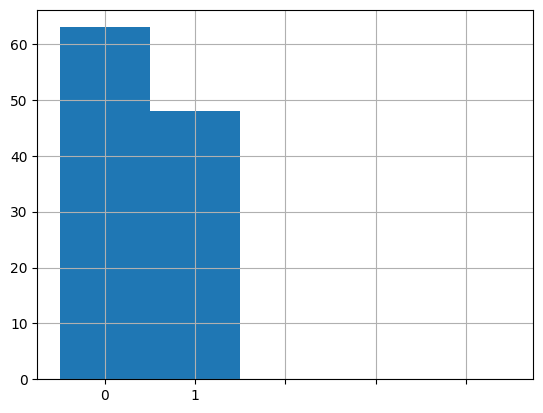

In [7]:
ax = S.hist(bins=np.arange(-0.5,5))
ax.set_xticks(range(0,5))
info

In [22]:
#BEFORE
import joblib
rf_morgan = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_RF_morgan.pkl')  
rf_maccs = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_RF_maccskey.pkl')
rf_modred = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_RF_modred.pkl')

svm_morgan = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_SVM_morgan.pkl')  
svm_maccs = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_SVM_maccskey.pkl')
svm_modred = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_SVM_modred.pkl')

xgb_morgan = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_XGB_morgan.pkl')  
xgb_maccs = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_XGB_maccskey.pkl')
xgb_modred = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_XGB_modred.pkl')

nn_morgan = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_NN_morgan.pkl')  
nn_maccs = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_NN_maccskey.pkl')
nn_modred = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_NN_modred.pkl')

lgbm_morgan = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_LGBM_morgan.pkl')  
lgbm_maccs = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_LGBM_maccskey.pkl')
lgbm_modred = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_LGBM_modred.pkl')


In [23]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score, classification_report


In [24]:
y_true = test_df['Outcome'].astype(int)  # Ensure it's of integer type, suitable for metrics calculation


In [25]:
# Consensus with probability average 

def predict_with_models_probabilities(test_df):
    # Expand descriptor kolom menjadi DataFrame
    X_morgan_full = pd.DataFrame(test_df['Morgan_Descriptors'].tolist())
    X_maccs       = pd.DataFrame(test_df['MACCS_Descriptors'].tolist())
    X_modred      = pd.DataFrame(test_df['Modred_Descriptor'].tolist())

    # Pastikan jumlah fitur sama dengan saat training
    X_morgan = X_morgan_full.iloc[:, :rf_morgan.n_features_in_]

    # Probabilities
    morgan_probs = rf_morgan.predict_proba(X_morgan)[:, 1]
    maccs_probs  = rf_maccs.predict_proba(X_maccs)[:, 1]
    modred_probs = rf_modred.predict_proba(X_modred)[:, 1]

    # Consensus: rata-rata probabilitas
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs], axis=0)
    final_predictions = (mean_probs > 0.5).astype(int)
    
    return final_predictions

# Run prediction
final_predictions = predict_with_models_probabilities(test_df)
test_df['Predictions'] = final_predictions

print(test_df[['SMILES', 'Predictions']])


                                                SMILES  Predictions
110                      CC(CN=Cc1ccccc1O)N=Cc1ccccc1O            0
35                              CCO[Si](CCCCl)(OCC)OCC            1
73   O=[N+]([O-])c1cc(S(=O)(=O)Nc2ccccc2)ccc1Nc1ccccc1            0
38                           Nc1cc(C(=O)O)cc(C(=O)O)c1            0
39   CS(=O)(=O)c1ccc(C(O)=C2C(=O)CCCC2=O)c(Cl)c1COC...            0
..                                                 ...          ...
53                                               CCSCC            1
51                                CCO[Si](C)(CCCCl)OCC            1
49                               O=CC1=C(Cl)C(C=O)CCC1            1
61                                      O=C1COC(=O)CO1            1
55                                   CCOC(=O)/C(C)=C/N            1

[111 rows x 2 columns]


In [26]:
# RF
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# Prediction Function 
def predict_probabilities_rf_from_pkl(test_df, rf_morgan, rf_maccs, rf_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :rf_morgan.n_features_in_]

    X_maccs = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :rf_maccs.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :rf_modred.n_features_in_]

    return {
        "Morgan": rf_morgan.predict_proba(X_morgan)[:, 1],
        "MACCS":  rf_maccs.predict_proba(X_maccs)[:, 1],
        "Modred": rf_modred.predict_proba(X_modred)[:, 1]
    }

# Evaluation Function
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }


# Consensus Function 
def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs_rf = predict_probabilities_rf_from_pkl(
    test_df,
    rf_morgan,
    rf_maccs,
    rf_modred
)

# Results
for model_name, y_prob in probs_rf.items():
    print(f"\n{model_name} RF Performance")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

consensus_probs_rf = consensus_probability(probs_rf)
consensus_metrics_rf = evaluate_model(y_true, consensus_probs_rf)

print("\nCONSENSUS RF (Morgan + MACCS + Modred)")
for k, v in consensus_metrics_rf.items():
    print(f"{k}: {v}")



Morgan RF Performance
Confusion Matrix: [[ 0 63]
 [ 0 48]]
Accuracy: 0.43243243243243246
AUC: 0.6035052910052909
F1 Score: 0.6037735849056604
Sensitivity: 1.0
Specificity: 0.0
CCR: 0.5
PPV (Precision): 0.43243243243243246
NPV: 0.0

MACCS RF Performance
Confusion Matrix: [[49 14]
 [12 36]]
Accuracy: 0.7657657657657657
AUC: 0.8356481481481481
F1 Score: 0.7346938775510204
Sensitivity: 0.75
Specificity: 0.7777777777777778
CCR: 0.7638888888888888
PPV (Precision): 0.72
NPV: 0.8032786885245902

Modred RF Performance
Confusion Matrix: [[44 19]
 [12 36]]
Accuracy: 0.7207207207207207
AUC: 0.8116732804232804
F1 Score: 0.6990291262135923
Sensitivity: 0.75
Specificity: 0.6984126984126984
CCR: 0.7242063492063492
PPV (Precision): 0.6545454545454545
NPV: 0.7857142857142857

CONSENSUS RF (Morgan + MACCS + Modred)
Confusion Matrix: [[40 23]
 [ 3 45]]
Accuracy: 0.7657657657657657
AUC: 0.8402777777777778
F1 Score: 0.7758620689655172
Sensitivity: 0.9375
Specificity: 0.6349206349206349
CCR: 0.7862103174603

In [29]:
# SVM
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

def predict_probabilities_from_pkl(test_df, svm_morgan, svm_maccs, svm_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :svm_morgan.n_features_in_]

    X_maccs = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :svm_maccs.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :svm_modred.n_features_in_]

    return {
        "Morgan": svm_morgan.predict_proba(X_morgan)[:, 1],
        "MACCS":  svm_maccs.predict_proba(X_maccs)[:, 1],
        "Modred": svm_modred.predict_proba(X_modred)[:, 1]
    }

def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs_svm = predict_probabilities_from_pkl(
    test_df,
    svm_morgan,
    svm_maccs,
    svm_modred
)

for model_name, y_prob in probs_svm.items():
    print(f"\n{model_name} SVM Performance")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

consensus_probs_svm = consensus_probability(probs_svm)
consensus_metrics_svm = evaluate_model(y_true, consensus_probs_svm)

print("\nCONSENSUS SVM (Morgan + MACCS + Modred)")
for k, v in consensus_metrics_svm.items():
    print(f"{k}: {v}")



Morgan SVM Performance
Confusion Matrix: [[ 1 62]
 [ 1 47]]
Accuracy: 0.43243243243243246
AUC: 0.5436507936507937
F1 Score: 0.5987261146496815
Sensitivity (Recall+): 0.9791666666666666
Specificity (Recall-): 0.015873015873015872
CCR: 0.4975198412698413
PPV (Precision): 0.43119266055045874
NPV: 0.5

MACCS SVM Performance
Confusion Matrix: [[50 13]
 [11 37]]
Accuracy: 0.7837837837837838
AUC: 0.8267195767195767
F1 Score: 0.7551020408163265
Sensitivity (Recall+): 0.7708333333333334
Specificity (Recall-): 0.7936507936507936
CCR: 0.7822420634920635
PPV (Precision): 0.74
NPV: 0.819672131147541

Modred SVM Performance
Confusion Matrix: [[52 11]
 [15 33]]
Accuracy: 0.7657657657657657
AUC: 0.8439153439153438
F1 Score: 0.717391304347826
Sensitivity (Recall+): 0.6875
Specificity (Recall-): 0.8253968253968254
CCR: 0.7564484126984127
PPV (Precision): 0.75
NPV: 0.7761194029850746

CONSENSUS SVM (Morgan + MACCS + Modred)
Confusion Matrix: [[41 22]
 [ 5 43]]
Accuracy: 0.7567567567567568
AUC: 0.8528439

In [31]:
# XGB
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# Prediction Function 
def predict_probabilities_from_pkl(test_df, xgb_morgan, xgb_maccs, xgb_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :xgb_morgan.n_features_in_]

    X_maccs = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :xgb_maccs.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :xgb_modred.n_features_in_]

    return {
        "Morgan": xgb_morgan.predict_proba(X_morgan)[:, 1],
        "MACCS":  xgb_maccs.predict_proba(X_maccs)[:, 1],
        "Modred": xgb_modred.predict_proba(X_modred)[:, 1]
    }

# Evaluation Function
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# Consensus Function 
def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs_xgb = predict_probabilities_from_pkl(
    test_df,
    xgb_morgan,
    xgb_maccs,
    xgb_modred
)

# Results
for model_name, y_prob in probs_xgb.items():
    print(f"\n{model_name} XGB Performance")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")
consensus_probs_xgb = consensus_probability(probs_xgb)
consensus_metrics_xgb = evaluate_model(y_true, consensus_probs_xgb)

print("\nCONSENSUS XGB (Morgan + MACCS + Modred)")
for k, v in consensus_metrics_xgb.items():
    print(f"{k}: {v}")




Morgan XGB Performance
Confusion Matrix: [[ 1 62]
 [ 1 47]]
Accuracy: 0.43243243243243246
AUC: 0.607473544973545
F1 Score: 0.5987261146496815
Sensitivity (Recall+): 0.9791666666666666
Specificity (Recall-): 0.015873015873015872
CCR: 0.4975198412698413
PPV (Precision): 0.43119266055045874
NPV: 0.5

MACCS XGB Performance
Confusion Matrix: [[48 15]
 [ 6 42]]
Accuracy: 0.8108108108108109
AUC: 0.8779761904761905
F1 Score: 0.8
Sensitivity (Recall+): 0.875
Specificity (Recall-): 0.7619047619047619
CCR: 0.8184523809523809
PPV (Precision): 0.7368421052631579
NPV: 0.8888888888888888

Modred XGB Performance
Confusion Matrix: [[47 16]
 [16 32]]
Accuracy: 0.7117117117117117
AUC: 0.8181216931216931
F1 Score: 0.6666666666666666
Sensitivity (Recall+): 0.6666666666666666
Specificity (Recall-): 0.746031746031746
CCR: 0.7063492063492063
PPV (Precision): 0.6666666666666666
NPV: 0.746031746031746

CONSENSUS XGB (Morgan + MACCS + Modred)
Confusion Matrix: [[41 22]
 [ 7 41]]
Accuracy: 0.7387387387387387
AUC

In [21]:
# NN 
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# Prediction Function 
def predict_probabilities_from_pkl(test_df, nn_morgan, nn_maccs, nn_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :nn_morgan.n_features_in_]

    X_maccs = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :nn_maccs.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :nn_modred.n_features_in_]

    return {
        "Morgan": nn_morgan.predict_proba(X_morgan)[:, 1],
        "MACCS":  nn_maccs.predict_proba(X_maccs)[:, 1],
        "Modred": nn_modred.predict_proba(X_modred)[:, 1]
    }

# Evaluation Function
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# Consensus Function 
def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs = predict_probabilities_from_pkl(
    test_df,
    nn_morgan,
    nn_maccs,
    nn_modred
)

# Results
for model_name, y_prob in probs.items():
    print(f"\n{model_name} Performance")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

consensus_probs_nn = consensus_probability(probs)
consensus_metrics_nn = evaluate_model(y_true, consensus_probs_nn)

print("\n CONSENSUS NN (Morgan + MACCS + Modred) ")
for k, v in consensus_metrics_nn.items():
    print(f"{k}: {v}")



Morgan Performance
Confusion Matrix: [[43 20]
 [34 14]]
Accuracy: 0.5135135135135135
AUC: 0.572420634920635
F1 Score: 0.34146341463414637
Sensitivity (Recall+): 0.2916666666666667
Specificity (Recall-): 0.6825396825396826
CCR: 0.48710317460317465
PPV (Precision): 0.4117647058823529
NPV: 0.5584415584415584

MACCS Performance
Confusion Matrix: [[48 15]
 [17 31]]
Accuracy: 0.7117117117117117
AUC: 0.7883597883597884
F1 Score: 0.6595744680851063
Sensitivity (Recall+): 0.6458333333333334
Specificity (Recall-): 0.7619047619047619
CCR: 0.7038690476190477
PPV (Precision): 0.6739130434782609
NPV: 0.7384615384615385

Modred Performance
Confusion Matrix: [[51 12]
 [14 34]]
Accuracy: 0.7657657657657657
AUC: 0.8273809523809523
F1 Score: 0.723404255319149
Sensitivity (Recall+): 0.7083333333333334
Specificity (Recall-): 0.8095238095238095
CCR: 0.7589285714285714
PPV (Precision): 0.7391304347826086
NPV: 0.7846153846153846

 CONSENSUS NN (Morgan + MACCS + Modred) 
Confusion Matrix: [[52 11]
 [20 28]]
A

In [19]:
# LGBM - Consensus
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# ==============================
# Prediction Function (PKL-based)
# ==============================
def predict_probabilities_from_pkl(test_df, lgbm_morgan, lgbm_maccs, lgbm_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :lgbm_morgan.n_features_in_]

    X_maccs = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :lgbm_maccs.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :lgbm_modred.n_features_in_]

    return {
        "Morgan": lgbm_morgan.predict_proba(X_morgan)[:, 1],
        "MACCS":  lgbm_maccs.predict_proba(X_maccs)[:, 1],
        "Modred": lgbm_modred.predict_proba(X_modred)[:, 1]
    }

# ==============================
# Evaluation Function
# ==============================
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# ==============================
# Consensus Function (Neutral)
# ==============================
def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

# ==============================
# RUN PREDICTION
# ==============================
probs = predict_probabilities_from_pkl(
    test_df,
    lgbm_morgan,
    lgbm_maccs,
    lgbm_modred
)

# ==============================
# PRINT INDIVIDUAL MODEL RESULTS
# ==============================
for model_name, y_prob in probs.items():
    print(f"\n===== {model_name} Performance =====")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

# ==============================
# CONSENSUS RESULT
# ==============================
consensus_probs_lgbm = consensus_probability(probs)
consensus_metrics_lgbm = evaluate_model(y_true, consensus_probs_lgbm)

print("\n===== CONSENSUS LGBM (Morgan + MACCS + Modred) =====")
for k, v in consensus_metrics_lgbm.items():
    print(f"{k}: {v}")



===== Morgan Performance =====
Confusion Matrix: [[ 0 63]
 [ 0 48]]
Accuracy: 0.43243243243243246
AUC: 0.6355820105820106
F1 Score: 0.6037735849056604
Sensitivity (Recall+): 1.0
Specificity (Recall-): 0.0
CCR: 0.5
PPV (Precision): 0.43243243243243246
NPV: 0.0

===== MACCS Performance =====
Confusion Matrix: [[47 16]
 [10 38]]
Accuracy: 0.7657657657657657
AUC: 0.8373015873015873
F1 Score: 0.7450980392156863
Sensitivity (Recall+): 0.7916666666666666
Specificity (Recall-): 0.746031746031746
CCR: 0.7688492063492063
PPV (Precision): 0.7037037037037037
NPV: 0.8245614035087719

===== Modred Performance =====
Confusion Matrix: [[51 12]
 [14 34]]
Accuracy: 0.7657657657657657
AUC: 0.8330026455026455
F1 Score: 0.723404255319149
Sensitivity (Recall+): 0.7083333333333334
Specificity (Recall-): 0.8095238095238095
CCR: 0.7589285714285714
PPV (Precision): 0.7391304347826086
NPV: 0.7846153846153846

===== CONSENSUS LGBM (Morgan + MACCS + Modred) =====
Confusion Matrix: [[39 24]
 [ 4 44]]
Accuracy: 0.7

In [20]:
# ==============================
# CONSENSUS ALL (RF + SVM + XGB + NN + LGBM)
# ==============================
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# ==============================
# Evaluation Function
# ==============================
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# ==============================
# STACK ALL MODEL CONSENSUS
# ==============================
all_model_probs = np.vstack([
    consensus_probs_rf,
    consensus_probs_svm,
    consensus_probs_xgb,
    consensus_probs_nn,
    consensus_probs_lgbm
])

# ==============================
# FINAL CONSENSUS (MEAN)
# ==============================
consensus_all_probs = all_model_probs.mean(axis=0)

# ==============================
# EVALUATION
# ==============================
consensus_all_metrics = evaluate_model(y_true, consensus_all_probs)

print("\n===== CONSENSUS ALL (RF + SVM + XGB + NN + LGBM) =====")
for k, v in consensus_all_metrics.items():
    print(f"{k}: {v}")



===== CONSENSUS ALL (RF + SVM + XGB + NN + LGBM) =====
Confusion Matrix: [[45 18]
 [ 6 42]]
Accuracy: 0.7837837837837838
AUC: 0.8627645502645502
F1 Score: 0.7777777777777778
Sensitivity (Recall+): 0.875
Specificity (Recall-): 0.7142857142857143
CCR: 0.7946428571428572
PPV (Precision): 0.7
NPV: 0.8823529411764706


In [ ]:
# CONSENSUS svm + rf + xgb
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# ==============================
# Evaluation Function
# ==============================
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# ==============================
# STACK ALL MODEL CONSENSUS
# ==============================
all_model_probs = np.vstack([
    consensus_probs_rf,
    consensus_probs_svm,
    consensus_probs_xgb,
])

# ==============================
# FINAL CONSENSUS (MEAN)
# ==============================
consensus_all_probs = all_model_probs.mean(axis=0)

# ==============================
# EVALUATION
# ==============================
consensus_all_metrics = evaluate_model(y_true, consensus_all_probs)

print("\n===== CONSENSUS ALL (RF + SVM + XGB ) =====")
for k, v in consensus_all_metrics.items():
    print(f"{k}: {v}")


In [ ]:
# ==============================
# RANDOM FOREST — CONSENSUS (SAME STYLE)
# ==============================

import pandas as pd

# ==============================
# PREPARE INPUT FEATURES
# ==============================

X_morgan = pd.DataFrame(
    test_df['Morgan_Descriptors'].tolist()
).iloc[:, :rf_morgan.n_features_in_]

X_maccs = pd.DataFrame(
    test_df['MACCS_Descriptors'].tolist()
).iloc[:, :rf_maccs.n_features_in_]

X_modred = pd.DataFrame(
    test_df['Modred_Descriptor'].tolist()
).iloc[:, :rf_modred.n_features_in_]

# ==============================
# LOAD PROBABILITIES
# ==============================

prob_rf_morgan = rf_morgan.predict_proba(X_morgan)[:, 1]
prob_rf_maccs  = rf_maccs.predict_proba(X_maccs)[:, 1]
prob_rf_modred = rf_modred.predict_proba(X_modred)[:, 1]

# ==============================
# PRINT CONSENSUS RESULT
# ==============================

print_consensus_result(
    "Random Forest",
    prob_rf_morgan,
    prob_rf_maccs,
    prob_rf_modred,
    y_true
)


In [ ]:
def predict_with_models_probabilities(test_df):
    # Expand kolom descriptor menjadi DataFrame
    X_morgan_full = pd.DataFrame(test_df['Morgan_Descriptors'].tolist())
    X_maccs       = pd.DataFrame(test_df['MACCS_Descriptors'].tolist())
    X_modred      = pd.DataFrame(test_df['Modred_Descriptor'].tolist())

    # Pastikan jumlah fitur sesuai dengan model
    X_morgan = X_morgan_full.iloc[:, :rf_morgan.n_features_in_]
    X_maccs  = X_maccs.iloc[:, :rf_maccs.n_features_in_]
    X_modred = X_modred.iloc[:, :rf_modred.n_features_in_]

    # Probabilities
    morgan_probs = rf_morgan.predict_proba(X_morgan)[:, 1]
    maccs_probs  = rf_maccs.predict_proba(X_maccs)[:, 1]
    modred_probs = rf_modred.predict_proba(X_modred)[:, 1]

    # Consensus: rata-rata probabilitas
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs], axis=0)
    final_predictions = (mean_probs > 0.5).astype(int)
    
    return final_predictions, mean_probs

# Run prediction
final_predictions, mean_probs = predict_with_models_probabilities(test_df)
test_df['Predictions'] = final_predictions
test_df['Mean_Probabilities'] = mean_probs

# y_true harus diambil dari kolom label aktual di test_df
# Contoh: jika kolom label bernama 'Outcome'
# y_true = test_df['Outcome'].astype(int)

print(test_df[['SMILES', 'Predictions', 'Mean_Probabilities']])

# Evaluasi
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:\n", conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

auc_score = roc_auc_score(y_true, mean_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value):", ppv)

npv = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value):", npv)


In [ ]:
#RF
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# ==============================
# Prediction Function (PKL-based)
# ==============================
def predict_probabilities_from_pkl(test_df, rf_morgan, rf_maccs, rf_modred):

    X_morgan = pd.DataFrame(test_df['Morgan_Descriptors'].tolist()).iloc[:, :rf_morgan.n_features_in_]
    X_maccs  = pd.DataFrame(test_df['MACCS_Descriptors'].tolist()).iloc[:, :rf_maccs.n_features_in_]
    X_modred = pd.DataFrame(test_df['Modred_Descriptor'].tolist()).iloc[:, :rf_modred.n_features_in_]

    return {
        "Morgan": rf_morgan.predict_proba(X_morgan)[:, 1],
        "MACCS":  rf_maccs.predict_proba(X_maccs)[:, 1],
        "Modred": rf_modred.predict_proba(X_modred)[:, 1]
    }

# ==============================
# Evaluation Function
# ==============================
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# ==============================
# Consensus Function (Neutral)
# ==============================
def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

# ==============================
# RUN PREDICTION
# ==============================
probs = predict_probabilities_from_pkl(
    test_df,
    rf_morgan,
    rf_maccs,
    rf_modred
)

# ==============================
# PRINT INDIVIDUAL MODEL RESULTS
# ==============================
for model_name, y_prob in probs.items():
    print(f"\n===== {model_name} Performance =====")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

# ==============================
# CONSENSUS RESULT
# ==============================
consensus_probs = consensus_probability(probs)
consensus_metrics = evaluate_model(y_true, consensus_probs)

print("\n===== CONSENSUS RF (Morgan + MACCS + Modred) =====")
for k, v in consensus_metrics.items():
    print(f"{k}: {v}")


In [ ]:
#SVM
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# ==============================
# Prediction Function (PKL-based)
# ==============================
def predict_probabilities_svm_from_pkl(test_df, svm_morgan, svm_maccs, svm_modred):

    X_morgan = pd.DataFrame(test_df['Morgan_Descriptors'].tolist()).iloc[:, :svm_morgan.n_features_in_]
    X_maccs  = pd.DataFrame(test_df['MACCS_Descriptors'].tolist()).iloc[:, :svm_maccs.n_features_in_]
    X_modred = pd.DataFrame(test_df['Modred_Descriptor'].tolist()).iloc[:, :svm_modred.n_features_in_]

    return {
        "Morgan": svm_morgan.predict_proba(X_morgan)[:, 1],
        "MACCS":  svm_maccs.predict_proba(X_maccs)[:, 1],
        "Modred": svm_modred.predict_proba(X_modred)[:, 1]
    }

# ==============================
# Evaluation Function
# ==============================
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# ==============================
# Consensus Function (Neutral)
# ==============================
def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

# ==============================
# RUN PREDICTION
# ==============================
probs_svm = predict_probabilities_svm_from_pkl(
    test_df,
    svm_morgan,
    svm_maccs,
    svm_modred
)

# ==============================
# PRINT INDIVIDUAL MODEL RESULTS
# ==============================
for model_name, y_prob in probs_svm.items():
    print(f"\n===== {model_name} SVM Performance =====")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

# ==============================
# CONSENSUS RESULT
# ==============================
consensus_probs_svm = consensus_probability(probs_svm)
consensus_metrics_svm = evaluate_model(y_true, consensus_probs_svm)

print("\n===== CONSENSUS SVM (Morgan + MACCS + Modred) =====")
for k, v in consensus_metrics_svm.items():
    print(f"{k}: {v}")


In [ ]:
# XGB
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# ==============================
# Prediction Function (PKL-based)
# ==============================
def predict_probabilities_xgb_from_pkl(test_df, xgb_morgan, xgb_maccs, xgb_modred):

    X_morgan = pd.DataFrame(test_df['Morgan_Descriptors'].tolist()).iloc[:, :xgb_morgan.n_features_in_]
    X_maccs  = pd.DataFrame(test_df['MACCS_Descriptors'].tolist()).iloc[:, :xgb_maccs.n_features_in_]
    X_modred = pd.DataFrame(test_df['Modred_Descriptor'].tolist()).iloc[:, :xgb_modred.n_features_in_]

    return {
        "Morgan": xgb_morgan.predict_proba(X_morgan)[:, 1],
        "MACCS":  xgb_maccs.predict_proba(X_maccs)[:, 1],
        "Modred": xgb_modred.predict_proba(X_modred)[:, 1]
    }

# ==============================
# Evaluation Function
# ==============================
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# ==============================
# Consensus Function (Neutral)
# ==============================
def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

# ==============================
# RUN PREDICTION
# ==============================
probs_xgb = predict_probabilities_xgb_from_pkl(
    test_df,
    xgb_morgan,
    xgb_maccs,
    xgb_modred
)

# ==============================
# PRINT INDIVIDUAL MODEL RESULTS
# ==============================
for model_name, y_prob in probs_xgb.items():
    print(f"\n===== {model_name} XGB Performance =====")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

# ==============================
# CONSENSUS RESULT
# ==============================
consensus_probs_xgb = consensus_probability(probs_xgb)
consensus_metrics_xgb = evaluate_model(y_true, consensus_probs_xgb)

print("\n===== CONSENSUS XGB (Morgan + MACCS + Modred) =====")
for k, v in consensus_metrics_xgb.items():
    print(f"{k}: {v}")


In [ ]:
# ==============================
# XGB — PKL-based Evaluation
# ==============================

import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# ==============================
# LOAD TRAINED XGB MODELS (.pkl)
# ==============================

xgb_morgan = joblib.load(
    'C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/'
    'Skin Irritation/model - pribadi/fingerprint descriptor (model)/'
    'Model_Skin Irr_toxicity_XGB_morgan.pkl'
)

xgb_maccs = joblib.load(
    'C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/'
    'Skin Irritation/model - pribadi/fingerprint descriptor (model)/'
    'Model_Skin Irr_toxicity_XGB_maccskey.pkl'
)

xgb_modred = joblib.load(
    'C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/'
    'Skin Irritation/model - pribadi/fingerprint descriptor (model)/'
    'Model_Skin Irr_toxicity_XGB_modred.pkl'
)

print("XGB models successfully loaded from .pkl files")

# ==============================
# Prediction Function (PKL-based)
# ==============================
def predict_probabilities_xgb_from_pkl(test_df, xgb_morgan, xgb_maccs, xgb_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :xgb_morgan.n_features_in_]

    X_maccs = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :xgb_maccs.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :xgb_modred.n_features_in_]

    return {
        "Morgan": xgb_morgan.predict_proba(X_morgan)[:, 1],
        "MACCS":  xgb_maccs.predict_proba(X_maccs)[:, 1],
        "Modred": xgb_modred.predict_proba(X_modred)[:, 1]
    }

# ==============================
# Evaluation Function
# ==============================
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# ==============================
# Consensus Function (Neutral)
# ==============================
def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

# ==============================
# RUN PREDICTION (INFERENCE ONLY)
# ==============================
probs_xgb = predict_probabilities_xgb_from_pkl(
    test_df,
    xgb_morgan,
    xgb_maccs,
    xgb_modred
)

# ==============================
# PRINT INDIVIDUAL MODEL RESULTS
# ==============================
for model_name, y_prob in probs_xgb.items():
    print(f"\n===== {model_name} XGB Performance =====")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

# ==============================
# CONSENSUS RESULT
# ==============================
consensus_probs_xgb = consensus_probability(probs_xgb)
consensus_metrics_xgb = evaluate_model(y_true, consensus_probs_xgb)

print("\n===== CONSENSUS XGB (Morgan + MACCS + Modred) =====")
for k, v in consensus_metrics_xgb.items():
    print(f"{k}: {v}")


In [ ]:
# ==============================
# NN — PKL-based Evaluation
# ==============================

import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# ==============================
# LOAD TRAINED NN MODELS (.pkl)
# ==============================

nn_morgan = joblib.load(
    'C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/'
    'Skin Irritation/model - pribadi/fingerprint descriptor (model)/'
    'Model_Skin Irr_toxicity_NN_morgan.pkl'
)

nn_maccs = joblib.load(
    'C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/'
    'Skin Irritation/model - pribadi/fingerprint descriptor (model)/'
    'Model_Skin Irr_toxicity_NN_maccskey.pkl'
)

nn_modred = joblib.load(
    'C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/'
    'Skin Irritation/model - pribadi/fingerprint descriptor (model)/'
    'Model_Skin Irr_toxicity_NN_modred.pkl'
)

print("NN models successfully loaded from .pkl files")

# ==============================
# Prediction Function (PKL-based)
# ==============================
def predict_probabilities_nn_from_pkl(test_df, nn_morgan, nn_maccs, nn_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :nn_morgan.n_features_in_]

    X_maccs = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :nn_maccs.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :nn_modred.n_features_in_]

    return {
        "Morgan": nn_morgan.predict_proba(X_morgan)[:, 1],
        "MACCS":  nn_maccs.predict_proba(X_maccs)[:, 1],
        "Modred": nn_modred.predict_proba(X_modred)[:, 1]
    }

# ==============================
# Evaluation Function
# ==============================
def evaluate_model(y_true, y_prob, threshold=0.55):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# ==============================
# Consensus Function (Neutral)
# ==============================
def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

# ==============================
# RUN PREDICTION (INFERENCE ONLY)
# ==============================
probs_nn = predict_probabilities_nn_from_pkl(
    test_df,
    nn_morgan,
    nn_maccs,
    nn_modred
)

# ==============================
# PRINT INDIVIDUAL MODEL RESULTS
# ==============================
for model_name, y_prob in probs_nn.items():
    print(f"\n===== {model_name} NN Performance =====")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

# ==============================
# CONSENSUS RESULT
# ==============================
consensus_probs_nn = consensus_probability(probs_nn)
consensus_metrics_nn = evaluate_model(y_true, consensus_probs_nn)

print("\n===== CONSENSUS NN (Morgan + MACCS + Modred) =====")
for k, v in consensus_metrics_nn.items():
    print(f"{k}: {v}")


In [ ]:
# ==============================
# LGBM — PKL-based Evaluation
# ==============================

import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# ==============================
# LOAD TRAINED LGBM MODELS (.pkl)
# ==============================

lgbm_morgan = joblib.load(
    'C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/'
    'Skin Irritation/model - pribadi/fingerprint descriptor (model)/'
    'Model_Skin Irr_toxicity_LGBM_morgan.pkl'
)

lgbm_maccs = joblib.load(
    'C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/'
    'Skin Irritation/model - pribadi/fingerprint descriptor (model)/'
    'Model_Skin Irr_toxicity_LGBM_maccskey.pkl'
)

lgbm_modred = joblib.load(
    'C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/'
    'Skin Irritation/model - pribadi/fingerprint descriptor (model)/'
    'Model_Skin Irr_toxicity_LGBM_modred.pkl'
)

print("LGBM models successfully loaded from .pkl files")

# ==============================
# Prediction Function (PKL-based)
# ==============================
def predict_probabilities_lgbm_from_pkl(test_df, lgbm_morgan, lgbm_maccs, lgbm_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :lgbm_morgan.n_features_in_]

    X_maccs = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :lgbm_maccs.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :lgbm_modred.n_features_in_]

    return {
        "Morgan": lgbm_morgan.predict_proba(X_morgan)[:, 1],
        "MACCS":  lgbm_maccs.predict_proba(X_maccs)[:, 1],
        "Modred": lgbm_modred.predict_proba(X_modred)[:, 1]
    }

# ==============================
# Evaluation Function
# ==============================
def evaluate_model(y_true, y_prob, threshold=0.55):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# ==============================
# Consensus Function (Neutral)
# ==============================
def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

# ==============================
# RUN PREDICTION (INFERENCE ONLY)
# ==============================
probs_lgbm = predict_probabilities_lgbm_from_pkl(
    test_df,
    lgbm_morgan,
    lgbm_maccs,
    lgbm_modred
)

# ==============================
# PRINT INDIVIDUAL MODEL RESULTS
# ==============================
for model_name, y_prob in probs_lgbm.items():
    print(f"\n===== {model_name} LGBM Performance =====")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

# ==============================
# CONSENSUS RESULT
# ==============================
consensus_probs_lgbm = consensus_probability(probs_lgbm)
consensus_metrics_lgbm = evaluate_model(y_true, consensus_probs_lgbm)

print("\n===== CONSENSUS LGBM (Morgan + MACCS + Modred) =====")
for k, v in consensus_metrics_lgbm.items():
    print(f"{k}: {v}")


In [ ]:
# ==============================
# FINAL CONSENSUS — ALL MODELS
# RF + SVM + XGB + NN + LGBM
# ==============================

import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# ==============================
# Evaluation Function
# ==============================
def evaluate_model(y_true, y_prob, threshold=0.55):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# ==============================
# FINAL CONSENSUS FUNCTION
# ==============================
def final_consensus_probability(
    consensus probs_rf,
    consensus probs_svm,
    consensus probs_xgb,
    consensus probs_nn,
    consensus probs_lgbm
):
    """
    Neutral meta-consensus:
    average of ALL model probabilities
    """

    all_probs = []

    for probs_dict in [consensus probs_rf, probs_svm, probs_xgb, probs_nn, probs_lgbm]:
        for _, probs in probs_dict.items():
            all_probs.append(probs)

    return np.mean(np.vstack(all_probs), axis=0)

# ==============================
# RUN FINAL CONSENSUS
# ==============================
final_probs = final_consensus_probability(
    probs_rf,     # dari RF
    probs_svm,    # dari SVM
    probs_xgb,    # dari XGB
    probs_nn,     # dari NN
    probs_lgbm    # dari LGBM
)

final_metrics = evaluate_model(y_true, final_probs)

print("\n===== FINAL CONSENSUS (RF + SVM + XGB + NN + LGBM) =====")
for k, v in final_metrics.items():
    print(f"{k}: {v}")


In [ ]:
#BEFORE
import joblib
rf_morgan = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_RF_morgan.pkl')  
rf_maccs = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_RF_maccskey.pkl')
rf_modred = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_RF_modred.pkl')

svm_morgan = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_SVM_morgan.pkl')  
svm_maccs = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_SVM_maccskey.pkl')
svm_modred = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_SVM_modred.pkl')

xgb_morgan = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_XGB_morgan.pkl')  
xgb_maccs = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_XGB_maccskey.pkl')
xgb_modred = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_XGB_modred.pkl')

nn_morgan = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_NN_morgan.pkl')  
nn_maccs = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_NN_maccskey.pkl')
nn_modred = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_NN_modred.pkl')

lgbm_morgan = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_LGBM_morgan.pkl')  
lgbm_maccs = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_LGBM_maccskey.pkl')
lgbm_modred = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_LGBM_modred.pkl')


In [ ]:
import joblib
rf_maccs = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_RF_maccskey.pkl')
rf_modred = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_RF_modred.pkl')
rf_morgan = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_RF2_morgan.pkl')  


svm_morgan = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_SVM_morgan.pkl')  
svm_maccs = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_SVM_maccskey.pkl')
svm_modred = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_SVM_modred.pkl')

xgb_morgan = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_XGB_morgan.pkl')  
xgb_maccs = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_XGB_maccskey.pkl')
xgb_modred = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_XGB_modred.pkl')

nn_morgan = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_NN_morgan.pkl')  
nn_maccs = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_NN_maccskey.pkl')
nn_modred = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_NN_modred.pkl')

lgbm_morgan = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_LGBM_morgan.pkl')  
lgbm_maccs = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_LGBM_maccskey.pkl')
lgbm_modred = joblib.load('C:/Users/User/Documents/KULIAH TELKOM S1/SKRIPSI/UJI COBA QSAR - PRIBADI/Skin Irritation/model - pribadi/fingerprint descriptor (model)/Model_Skin Irr_toxicity_LGBM_modred.pkl')


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score, classification_report


In [ ]:
y_true = test_df['Outcome'].astype(float).astype(int)


In [ ]:
def predict_with_models_probabilities(test_df):
    # Pastikan descriptor sudah dalam bentuk DataFrame dengan jumlah kolom sama seperti training
    X_morgan = pd.DataFrame(test_df['Morgan_Descriptors'].tolist())   # expand list ke kolom
    X_maccs  = pd.DataFrame(test_df['MACCS_Descriptors'].tolist())
    X_modred = pd.DataFrame(test_df['Modred_Descriptor'].tolist())

    # Probabilities
    morgan_probs = rf_morgan.predict_proba(X_morgan)[:, 1]
    maccs_probs  = rf_maccs.predict_proba(X_maccs)[:, 1]
    modred_probs = rf_modred.predict_proba(X_modred)[:, 1]

    # Consensus: rata-rata probabilitas
    mean_probs = np.mean([morgan_probs, maccs_probs, modred_probs], axis=0)
    final_predictions = (mean_probs > 0.5).astype(int)
    
    return final_predictions

# Run prediction
final_predictions = predict_with_models_probabilities(test_df)
test_df['Predictions'] = final_predictions

print(test_df[['SMILES', 'Predictions']])


In [ ]:
# Cek shape data dan jumlah fitur yang diharapkan model
import numpy as np
import pandas as pd

# Morgan
X_morgan = pd.DataFrame(test_df['Morgan_Descriptors'].tolist())
print("Morgan test shape:", X_morgan.shape)
print("Morgan model expects:", rf_morgan.n_features_in_)

# MACCS
X_maccs = pd.DataFrame(test_df['MACCS_Descriptors'].tolist())
print("MACCS test shape:", X_maccs.shape)
print("MACCS model expects:", rf_maccs.n_features_in_)

# Mordred
X_modred = pd.DataFrame(test_df['Modred_Descriptor'].tolist())
print("Modred test shape:", X_modred.shape)
print("Modred model expects:", rf_modred.n_features_in_)


In [ ]:
uzeeee thisss